If any of your imports aren't working use the cell below with the command %pip install (package)

In [ ]:
%pip install pandas

In this file we examine using linear regression as a machine learning model. 
Linear regression finds a line of best fit to predict outcomes. 
Just like in the sciences, our line of best fit will be based on a dependent variable (the y axis), and an independent variable(s) (the x axis).

To achieve our goal of using linear regression we will require the following imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In this example we will use random data points that loosely follow a straight line

In [ ]:
np.random.seed(42)

X = np.random.rand(50, 1) * 100  

Y = 3.5 * X + np.random.randn(50, 1) * 20 

Here we define our model as using linear regression and fit it to the data we have provided

In [ ]:
model = LinearRegression()
model.fit(X, Y)

Our prediction below establishes the y values for the line of best fit

In [ ]:
Y_pred = model.predict(X)

Here we are just making a graph using the data we have created as a scatter plot (dots) and our line of best fit to compare the two

In [ ]:
plt.figure(figsize=(8,6)) 
plt.scatter(X, Y, color='blue', label='Data Points') 
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line') 
plt.title('Linear Regression on Random Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

We can also retrieve the coefficient and intercept values to see what they are

In [ ]:
print("Slope (Coefficient):", model.coef_[0][0])
print("Intercept:", model.intercept_[0])

Now we can make predictions using our line of best fit. Below I have predicted what y value we should have at x = 60

In [ ]:
print(model.predict([[60]]))

If we look at the graph we can see that it looks about right

We can further determine the fit of the line by examining the r squared value (coefficient of determination). The closer to 1 it is the better fit a line is

In [ ]:
r2 = r2_score(Y, model.predict(X))

print(r2)

With a dataset, we can split it up into training and testing data in which we can find the r2 value for both to determine whether this is a good model.

To use and manipulate datasets in Python, we use the pandas library (no I don't know why it's called that) 

In [2]:
import pandas as pd

Here we are reading our dataset and displaying the columns and the first few rows (by the way, df stands for dataframe)

In [3]:
df = pd.read_csv('data/Salary_dataset.csv')
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


Let's plot the data to get an idea of its shape

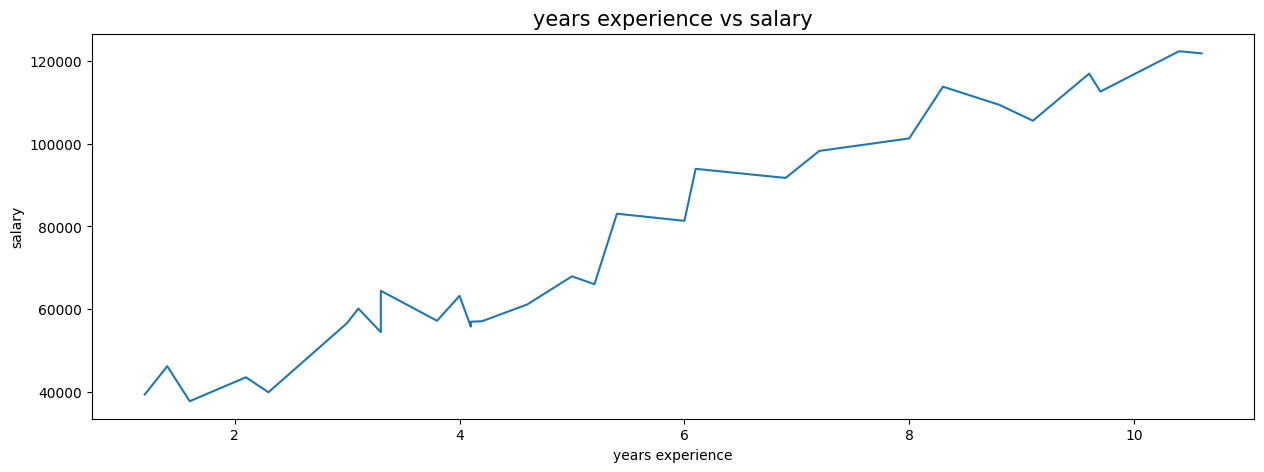

In [5]:
plt.figure(figsize=(15,5))
plt.plot(df.get('YearsExperience'), df.get('Salary'))
plt.title('years experience vs salary', fontsize=15)
plt.ylabel('salary')
plt.xlabel('years experience')
plt.show()

With such a simple dataset we don't need to change, add or remove any columns so we can just split it into training and testing data.

In [6]:
x = df.iloc[:, :1]  # independent
y = df.iloc[:, 1:]  # dependent


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
lin_model = LinearRegression()
lin_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


We can check our coefficient of determination

In [7]:
r2_2 = r2_score(y, lin_model.predict(x))

print(r2_2)

0.9566628347576891


And model our line of best fit

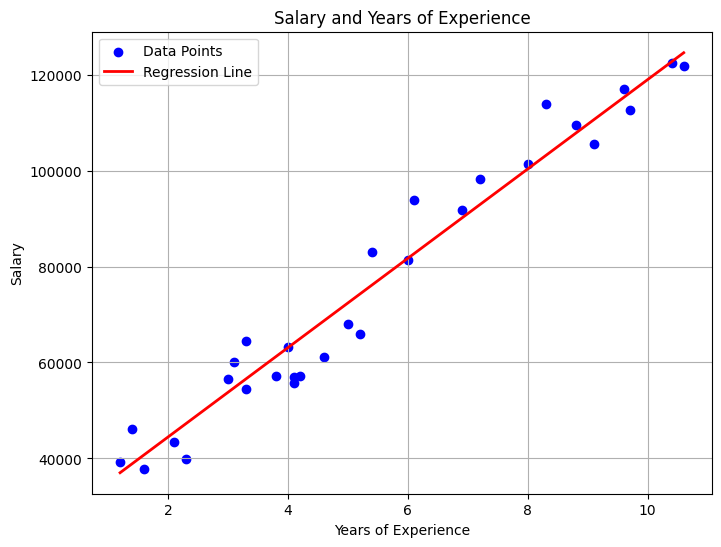

In [8]:
y_pred = lin_model.predict(x)
plt.figure(figsize=(8,6)) 
plt.scatter(x, y, color='blue', label='Data Points') 
plt.plot(x, y_pred, color='red', linewidth=2, label='Regression Line') 
plt.title('Salary and Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

Lastly we can test our model on the test sample

In [9]:
r2_test = r2_score(y_test, lin_model.predict(x_test))

print(r2_2)

0.9566628347576891
